# 01 – Spawn-Rate Optimization

This notebook documents the denominator correction and its impact on spawn-rate calibration.

Workflow in this notebook:
1. Build reusable foundations (data loading + helper functions).
2. Compute wrong vs corrected rates and key bias metrics.
3. Show one informative heatmap and core numeric checks.
4. Run a holdout backtest and compare model variants.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pm4py

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(42)

def detect_project_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for p in candidates:
        if (p / "spawn_rates").exists() and (p / "data").exists():
            return p
    return Path.cwd()

PROJECT_ROOT = detect_project_root()

EVENT_LOG_PATH = str(PROJECT_ROOT / "data" / "BPI Challenge 2017.xes.gz")
TIMESTAMP_COL = "time:timestamp"
ACTIVITY_COL = "concept:name"
CASE_COL = "case:concept:name"
START_ACTIVITY = "A_Create Application"
HOLIDAY_PATH = None
START_DATE = None
END_DATE = None

def resolve_event_log_path(path_str: str) -> Path:
    path = Path(path_str)
    if path.exists():
        return path

    candidates = [
        PROJECT_ROOT / "sim_output" / "final_simulation_log.csv",
        PROJECT_ROOT / "data" / "BPI Challenge 2017.xes.gz",
        PROJECT_ROOT / "data" / "DATA.xml",
    ]
    existing = [str(candidate) for candidate in candidates if candidate.exists()]
    hint = (
        f"Configured EVENT_LOG_PATH not found: {path_str}. "
        f"Existing candidates: {existing if existing else 'none'}"
    )
    raise FileNotFoundError(hint)

def load_event_log(path: Path) -> pd.DataFrame:
    suffixes = "".join(path.suffixes).lower()
    if suffixes.endswith(".xes") or suffixes.endswith(".xes.gz"):
        return pm4py.convert_to_dataframe(pm4py.read_xes(str(path)))
    return pd.read_csv(path)

def extract_arrivals(events: pd.DataFrame) -> pd.DataFrame:
    missing_for_arrivals = [col for col in [CASE_COL, TIMESTAMP_COL] if col not in events.columns]
    if missing_for_arrivals:
        raise ValueError(
            f"Cannot extract arrivals, missing columns {missing_for_arrivals}. "
            f"Available columns: {list(events.columns)}"
        )

    work = events.copy()
    work[TIMESTAMP_COL] = pd.to_datetime(work[TIMESTAMP_COL], errors="coerce")
    work = work.dropna(subset=[TIMESTAMP_COL])

    if ACTIVITY_COL in work.columns and START_ACTIVITY:
        starts = work[work[ACTIVITY_COL] == START_ACTIVITY].copy()
        if len(starts) > 0:
            work = starts

    arrivals_df = (
        work.groupby(CASE_COL, as_index=False)[TIMESTAMP_COL]
        .min()
        .sort_values(TIMESTAMP_COL)
    )
    return arrivals_df

def build_wrong_and_correct_tables(arrivals_df: pd.DataFrame, holidays_set: set) -> tuple[dict, dict]:
    data = arrivals_df.copy()
    data["date"] = data[TIMESTAMP_COL].dt.floor("D")
    data["weekday"] = data[TIMESTAMP_COL].dt.weekday
    data["hour"] = data[TIMESTAMP_COL].dt.hour
    data["is_holiday"] = data["date"].isin(holidays_set)

    counts = data.groupby(["weekday", "hour", "is_holiday"]).size().rename("count")

    days_wrong = (
        data.groupby(["weekday", "hour", "is_holiday"])["date"]
        .nunique()
        .rename("days_wrong")
    )
    wrong_table = (counts / days_wrong).to_dict()

    calendar = pd.DataFrame({
        "date": pd.date_range(data["date"].min(), data["date"].max(), freq="D")
    })
    calendar["weekday"] = calendar["date"].dt.weekday
    calendar["is_holiday"] = calendar["date"].isin(holidays_set)

    day_exposure = (
        calendar.groupby(["weekday", "is_holiday"])
        .size()
        .rename("day_exposure")
        .reset_index()
    )

    rates = counts.reset_index().merge(day_exposure, on=["weekday", "is_holiday"], how="left")
    rates["rate_correct"] = rates["count"] / rates["day_exposure"]
    correct_table = {
        (int(r.weekday), int(r.hour), bool(r.is_holiday)): float(r.rate_correct)
        for r in rates.itertuples(index=False)
    }
    return wrong_table, correct_table

def build_recency_weighted_table(arrivals_df: pd.DataFrame, holidays_set: set, half_life_days: int = 60) -> dict:
    data = arrivals_df.copy()
    data["date"] = data[TIMESTAMP_COL].dt.floor("D")
    data["weekday"] = data[TIMESTAMP_COL].dt.weekday
    data["hour"] = data[TIMESTAMP_COL].dt.hour
    data["is_holiday"] = data["date"].isin(holidays_set)

    ref_date = data["date"].max()
    age_days = (ref_date - data["date"]).dt.days.astype(float)
    data["weight"] = np.power(0.5, age_days / float(half_life_days))

    weighted_counts = (
        data.groupby(["weekday", "hour", "is_holiday"])["weight"]
        .sum()
        .rename("weighted_count")
        .reset_index()
    )

    unique_days = data[["date"]].drop_duplicates().copy()
    unique_days["weekday"] = unique_days["date"].dt.weekday
    unique_days["is_holiday"] = unique_days["date"].isin(holidays_set)
    day_age = (ref_date - unique_days["date"]).dt.days.astype(float)
    unique_days["weight"] = np.power(0.5, day_age / float(half_life_days))

    weighted_exposure = (
        unique_days.groupby(["weekday", "is_holiday"])["weight"]
        .sum()
        .rename("weighted_exposure")
        .reset_index()
    )

    rates = weighted_counts.merge(weighted_exposure, on=["weekday", "is_holiday"], how="left")
    rates["rate"] = rates["weighted_count"] / rates["weighted_exposure"]

    return {
        (int(r.weekday), int(r.hour), bool(r.is_holiday)): float(r.rate)
        for r in rates.itertuples(index=False)
    }

def expected_total_from_table(rate_table: dict, dates: pd.DatetimeIndex, holidays_set: set) -> float:
    total = 0.0
    for day in dates:
        wd = int(day.weekday())
        hol = bool(day.floor("D") in holidays_set)
        for hr in range(24):
            total += rate_table.get((wd, hr, hol), 0.0)
    return total

def evaluate_on_test(arrivals_test: pd.DataFrame, rate_table: dict, holidays_set: set, label: str) -> dict:
    test = arrivals_test.copy()
    test["date"] = test[TIMESTAMP_COL].dt.floor("D")
    test["weekday"] = test[TIMESTAMP_COL].dt.weekday
    test["hour"] = test[TIMESTAMP_COL].dt.hour
    test["is_holiday"] = test["date"].isin(holidays_set)

    test_days = pd.date_range(test["date"].min(), test["date"].max(), freq="D")
    n_days = len(test_days)
    observed_total = len(test)
    expected_total = expected_total_from_table(rate_table, test_days, holidays_set)
    observed_daily = observed_total / n_days
    expected_daily = expected_total / n_days

    observed_slot = test.groupby(["weekday", "hour", "is_holiday"]).size().rename("obs_count").reset_index()

    exposure = pd.DataFrame({"date": test_days})
    exposure["weekday"] = exposure["date"].dt.weekday
    exposure["is_holiday"] = exposure["date"].isin(holidays_set)
    exposure = exposure.groupby(["weekday", "is_holiday"]).size().rename("exposure_days").reset_index()

    rows = []
    for wd in range(7):
        for hr in range(24):
            for hol in [False, True]:
                rows.append({
                    "weekday": wd,
                    "hour": hr,
                    "is_holiday": hol,
                    "pred_rate": rate_table.get((wd, hr, hol), 0.0),
                })
    pred_slot = pd.DataFrame(rows).merge(exposure, on=["weekday", "is_holiday"], how="left")
    pred_slot["exposure_days"] = pred_slot["exposure_days"].fillna(0)
    pred_slot["pred_count"] = pred_slot["pred_rate"] * pred_slot["exposure_days"]

    slot_cmp = pred_slot.merge(observed_slot, on=["weekday", "hour", "is_holiday"], how="left")
    slot_cmp["obs_count"] = slot_cmp["obs_count"].fillna(0)
    slot_cmp["abs_err"] = (slot_cmp["pred_count"] - slot_cmp["obs_count"]).abs()
    wmape = slot_cmp["abs_err"].sum() / max(slot_cmp["obs_count"].sum(), 1.0)

    non_hol = slot_cmp[slot_cmp["is_holiday"] == False].copy()
    non_hol["obs_rate"] = non_hol["obs_count"] / non_hol["exposure_days"].replace(0, np.nan)
    non_hol["obs_rate"] = non_hol["obs_rate"].fillna(0)
    heatmap_mae = (non_hol["pred_rate"] - non_hol["obs_rate"]).abs().mean()

    daily_obs = test.groupby("date").size().reindex(test_days, fill_value=0)
    window = 14
    obs_14, pred_14 = [], []
    if len(test_days) >= window:
        for start in range(0, len(test_days) - window + 1):
            chunk = test_days[start:start + window]
            obs_14.append(float(daily_obs.loc[chunk].sum()))
            pred_14.append(float(expected_total_from_table(rate_table, chunk, holidays_set)))
    obs_14 = np.array(obs_14, dtype=float)
    pred_14 = np.array(pred_14, dtype=float)
    mape_14 = (np.abs(pred_14 - obs_14) / np.maximum(obs_14, 1.0)).mean() if len(obs_14) else np.nan

    print(f"\n=== Holdout Backtest: {label} ===")
    print(f"days_test={n_days}")
    print(f"daily_real={observed_daily:.2f}  daily_model={expected_daily:.2f}  daily_gap_pct={(expected_daily/observed_daily - 1)*100:.2f}")
    print(f"slot_wmape={wmape:.3f}")
    print(f"heatmap_mae_nonholiday={heatmap_mae:.4f}")
    if len(obs_14):
        print(f"mape_14day={mape_14:.3f}  windows={len(obs_14)}")
    else:
        print("mape_14day=nan  windows=0 (need >=14 holdout days)")

    return {
        "label": label,
        "days_test": n_days,
        "daily_real": observed_daily,
        "daily_model": expected_daily,
        "daily_gap_pct": (expected_daily / observed_daily - 1) * 100,
        "slot_wmape": wmape,
        "heatmap_mae_nonholiday": heatmap_mae,
        "mape_14day": mape_14,
    }

**Interpretation:** This setup cell builds all reusable foundations (path detection, log loading, arrivals extraction, rate builders, and evaluation helpers).
These definitions are necessary because the next cells reuse them to keep the notebook consistent and reproducible.

## Step 1 — Load arrivals and quantify denominator bias

This cell loads arrivals, computes wrong vs corrected rate tables, and reports the core bias statistics.

In [2]:
event_log_path = resolve_event_log_path(EVENT_LOG_PATH)
events = load_event_log(event_log_path)
arrivals = extract_arrivals(events)

if START_DATE:
    arrivals = arrivals[arrivals[TIMESTAMP_COL] >= pd.to_datetime(START_DATE)]
if END_DATE:
    arrivals = arrivals[arrivals[TIMESTAMP_COL] <= pd.to_datetime(END_DATE)]

arrivals["date"] = arrivals[TIMESTAMP_COL].dt.floor("D")
arrivals["weekday"] = arrivals[TIMESTAMP_COL].dt.weekday
arrivals["hour"] = arrivals[TIMESTAMP_COL].dt.hour

if HOLIDAY_PATH:
    holidays = pd.read_csv(HOLIDAY_PATH)
    holiday_dates = set(pd.to_datetime(holidays["date"]).dt.floor("D"))
else:
    holiday_dates = set()

arrivals["is_holiday"] = arrivals["date"].isin(holiday_dates)

print(f"Rows: {len(arrivals):,}")
print(f"Period: {arrivals['date'].min().date()} .. {arrivals['date'].max().date()}")

counts = arrivals.groupby(["weekday", "hour", "is_holiday"]).size().rename("count")
days_wrong = arrivals.groupby(["weekday", "hour", "is_holiday"])["date"].nunique().rename("days_wrong")
rate_wrong = (counts / days_wrong).rename("rate_wrong")

calendar = pd.DataFrame({"date": pd.date_range(arrivals["date"].min(), arrivals["date"].max(), freq="D")})
calendar["weekday"] = calendar["date"].dt.weekday
calendar["is_holiday"] = calendar["date"].isin(holiday_dates)
day_exposure = calendar.groupby(["weekday", "is_holiday"]).size().rename("day_exposure")

rate_df = counts.to_frame().join(days_wrong, how="left").reset_index()
rate_df = rate_df.merge(day_exposure.reset_index(), on=["weekday", "is_holiday"], how="left")
rate_df["rate_wrong"] = rate_df["count"] / rate_df["days_wrong"]
rate_df["rate_correct"] = rate_df["count"] / rate_df["day_exposure"]
rate_df["bias_factor"] = rate_df["rate_wrong"] / rate_df["rate_correct"]

print("Mean bias factor:", rate_df["bias_factor"].mean().round(3))
print("Median bias factor:", rate_df["bias_factor"].median().round(3))
print("95% quantile bias factor:", rate_df["bias_factor"].quantile(0.95).round(3))

/Users/lucashi/TUM/Praktikum/Group Exercise/bppso-groupwork/.venv/lib/python3.11/site-packages/pm4py/utils.py:987: UserWarning: In the current version, the import/export operation uses `rustxes` by default for importing/exporting files faster. Please uninstall `rustxes` to revert the behavior.
  warnings.warn("In the current version, the import/export operation uses `rustxes` by default for importing/exporting files faster. Please uninstall `rustxes` to revert the behavior.")


Rows: 31,509
Period: 2016-01-01 .. 2016-12-31
Mean bias factor: 2.373
Median bias factor: 1.094
95% quantile bias factor: 8.667


**Interpretation:** If mean/median bias factor is clearly above 1.0, the old denominator systematically inflates rates.
This confirms that rare slots are overestimated when only days-with-arrivals are counted.

## Step 2 — Compare daily volume, inspect one example slot, and plot one informative heatmap

This cell focuses on actionable outputs: daily totals, one concrete slot example, and a single corrected-rate heatmap.

Real avg cases/day:      86.09
Model avg/day (wrong):   95.72
Model avg/day (correct): 86.09

Example Monday 03:00 (non-holiday)
count=8, days_wrong=8, day_exposure=52
rate_wrong=1.0000, rate_correct=0.1538, bias_factor=6.50x

Top 10 highest-bias non-holiday slots:


,weekday,hour,count,days_wrong,day_exposure,bias_factor
122,5,2,5,4,53,13.250000
98,4,2,6,5,53,10.600000
124,5,4,5,5,53,10.600000
73,3,1,6,5,52,10.400000
146,6,2,5,5,52,10.400000
123,5,3,6,6,53,8.833333
121,5,1,6,6,53,8.833333
74,3,2,6,6,52,8.666667
2,0,2,6,6,52,8.666667
148,6,4,6,6,52,8.666667


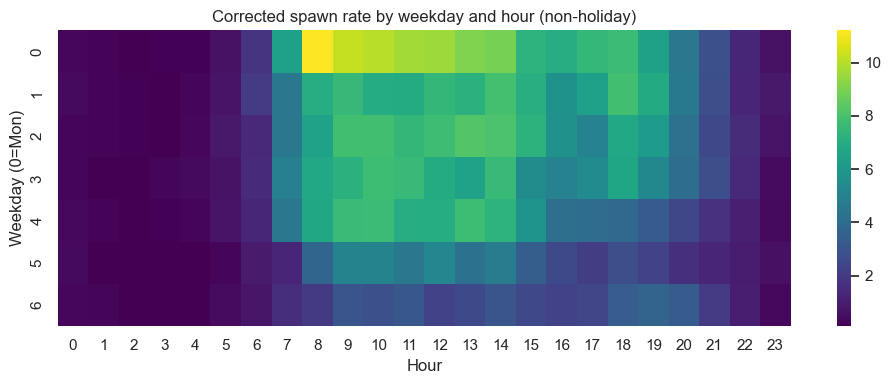


14-day expectation:
Real reference:      1205.3
Wrong-rate model:    1340.1
Correct-rate model:  1205.3
Excess wrong vs real: 11.2%
rate_table_correct entries: 168


In [3]:
avg_daily_wrong = 0.0
avg_daily_correct = 0.0
for (wd, hr, hol), grp in rate_df.groupby(["weekday", "hour", "is_holiday"]):
    weight_day = ((calendar["weekday"].eq(wd) & calendar["is_holiday"].eq(hol)).mean())
    avg_daily_wrong += grp["rate_wrong"].iloc[0] * weight_day
    avg_daily_correct += grp["rate_correct"].iloc[0] * weight_day

real_daily = arrivals.groupby("date").size().mean()
print(f"Real avg cases/day:      {real_daily:.2f}")
print(f"Model avg/day (wrong):   {avg_daily_wrong:.2f}")
print(f"Model avg/day (correct): {avg_daily_correct:.2f}")

example = rate_df.query("weekday == 0 and hour == 3 and is_holiday == False")
if len(example):
    row = example.iloc[0]
    print("\nExample Monday 03:00 (non-holiday)")
    print(f"count={int(row['count'])}, days_wrong={int(row['days_wrong'])}, day_exposure={int(row['day_exposure'])}")
    print(f"rate_wrong={row['rate_wrong']:.4f}, rate_correct={row['rate_correct']:.4f}, bias_factor={row['bias_factor']:.2f}x")

top_bias = (
    rate_df[rate_df["is_holiday"] == False]
    .sort_values("bias_factor", ascending=False)
    [["weekday", "hour", "count", "days_wrong", "day_exposure", "bias_factor"]]
    .head(10)
)
print("\nTop 10 highest-bias non-holiday slots:")
display(top_bias)

heat = (
    rate_df[rate_df["is_holiday"] == False]
    .pivot_table(index="weekday", columns="hour", values="rate_correct", aggfunc="mean")
    .reindex(index=[0, 1, 2, 3, 4, 5, 6])
)

plt.figure(figsize=(10, 4))
sns.heatmap(heat, cmap="viridis")
plt.title("Corrected spawn rate by weekday and hour (non-holiday)")
plt.xlabel("Hour")
plt.ylabel("Weekday (0=Mon)")
plt.tight_layout()
plt.show()

horizon_days = 14
sim_wrong = avg_daily_wrong * horizon_days
sim_correct = avg_daily_correct * horizon_days
real_ref = real_daily * horizon_days
print(f"\n{horizon_days}-day expectation:")
print(f"Real reference:      {real_ref:.1f}")
print(f"Wrong-rate model:    {sim_wrong:.1f}")
print(f"Correct-rate model:  {sim_correct:.1f}")
print(f"Excess wrong vs real: {((sim_wrong / real_ref) - 1) * 100:.1f}%")

rate_table_correct = {
    (int(r.weekday), int(r.hour), bool(r.is_holiday)): float(r.rate_correct)
    for r in rate_df.itertuples(index=False)
}
print(f"rate_table_correct entries: {len(rate_table_correct)}")

**Interpretation:** The corrected model should align much better with real daily volume, while the old model over-predicts.
The table of top biased slots gives a concrete numeric explanation without needing a second bias heatmap.

## Step 3 — Holdout backtest and model comparison

This cell evaluates wrong vs corrected vs recency-weighted variants on a temporal holdout set.

In [4]:
arrivals_bt = arrivals[[CASE_COL, TIMESTAMP_COL]].copy().sort_values(TIMESTAMP_COL)
arrivals_bt["date"] = arrivals_bt[TIMESTAMP_COL].dt.floor("D")
all_days = pd.Series(arrivals_bt["date"].sort_values().unique())

split_idx = int(len(all_days) * 0.7)
if split_idx < 14 or (len(all_days) - split_idx) < 14:
    raise ValueError("Not enough days for train/test backtest (need >= 28 distinct days).")

train_days = set(all_days.iloc[:split_idx])
test_days = set(all_days.iloc[split_idx:])
arrivals_train = arrivals_bt[arrivals_bt["date"].isin(train_days)].copy()
arrivals_test = arrivals_bt[arrivals_bt["date"].isin(test_days)].copy()

wrong_table_bt, correct_table_bt = build_wrong_and_correct_tables(arrivals_train, holiday_dates)
recency_30 = build_recency_weighted_table(arrivals_train, holiday_dates, half_life_days=30)
recency_60 = build_recency_weighted_table(arrivals_train, holiday_dates, half_life_days=60)
recency_90 = build_recency_weighted_table(arrivals_train, holiday_dates, half_life_days=90)

results = []
results.append(evaluate_on_test(arrivals_test, wrong_table_bt, holiday_dates, "WRONG denominator"))
results.append(evaluate_on_test(arrivals_test, correct_table_bt, holiday_dates, "CORRECT denominator"))
results.append(evaluate_on_test(arrivals_test, recency_30, holiday_dates, "RECENCY half_life=30d"))
results.append(evaluate_on_test(arrivals_test, recency_60, holiday_dates, "RECENCY half_life=60d"))
results.append(evaluate_on_test(arrivals_test, recency_90, holiday_dates, "RECENCY half_life=90d"))

summary = pd.DataFrame(results)
summary["abs_daily_gap_pct"] = summary["daily_gap_pct"].abs()
summary["rank_score"] = (
    0.45 * summary["slot_wmape"]
    + 0.35 * summary["heatmap_mae_nonholiday"]
    + 0.20 * summary["abs_daily_gap_pct"] / 100.0
)
summary = summary.sort_values("rank_score").reset_index(drop=True)

print("\n=== Model Ranking (lower is better) ===")
print(summary[["label", "daily_gap_pct", "slot_wmape", "heatmap_mae_nonholiday", "mape_14day", "rank_score"]].to_string(index=False))
summary


=== Holdout Backtest: WRONG denominator ===
days_test=110
daily_real=89.99  daily_model=94.47  daily_gap_pct=4.98
slot_wmape=0.210
heatmap_mae_nonholiday=0.7881
mape_14day=0.098  windows=97

=== Holdout Backtest: CORRECT denominator ===
days_test=110
daily_real=89.99  daily_model=84.59  daily_gap_pct=-6.00
slot_wmape=0.141
heatmap_mae_nonholiday=0.5266
mape_14day=0.101  windows=97

=== Holdout Backtest: RECENCY half_life=30d ===
days_test=110
daily_real=89.99  daily_model=96.57  daily_gap_pct=7.31
slot_wmape=0.213
heatmap_mae_nonholiday=0.7984
mape_14day=0.102  windows=97

=== Holdout Backtest: RECENCY half_life=60d ===
days_test=110
daily_real=89.99  daily_model=92.20  daily_gap_pct=2.45
slot_wmape=0.173
heatmap_mae_nonholiday=0.6471
mape_14day=0.096  windows=97

=== Holdout Backtest: RECENCY half_life=90d ===
days_test=110
daily_real=89.99  daily_model=89.89  daily_gap_pct=-0.11
slot_wmape=0.157
heatmap_mae_nonholiday=0.5905
mape_14day=0.095  windows=97

=== Model Ranking (lower is 

,label,days_test,daily_real,daily_model,daily_gap_pct,slot_wmape,heatmap_mae_nonholiday,mape_14day,abs_daily_gap_pct,rank_score
0,CORRECT denominator,110,89.990909,84.588752,-6.003003,0.140604,0.526582,0.100851,6.003003,0.259582
1,RECENCY half_life=90d,110,89.990909,89.888248,-0.114079,0.157495,0.590545,0.094642,0.114079,0.277791
2,RECENCY half_life=60d,110,89.990909,92.196395,2.450787,0.172625,0.647131,0.095986,2.450787,0.309079
3,WRONG denominator,110,89.990909,94.469221,4.976404,0.210192,0.788149,0.097978,4.976404,0.380391
4,RECENCY half_life=30d,110,89.990909,96.566253,7.306676,0.213083,0.798355,0.101836,7.306676,0.389925


**Interpretation:** This ranking summarizes which variant gives the best trade-off between volume calibration and structural fit.
Use this output to justify the selected default in the separate half-life selection notebook.

## Report Outcome

- The denominator fix removes the systematic overestimation of rare slots.
- The holdout evaluation highlights the trade-off between structural fit and volume calibration.
- These findings are used in the half-life selection notebook.